## Classification

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
# Missing Data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
df[["age"]] = imp_median.fit_transform(df[["age"]])

imp_freq = SimpleImputer(strategy = "most_frequent")
df[["embarked"]] = imp_freq.fit_transform(df[["embarked"]])

In [8]:
# Encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

In [9]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [10]:
X = df[["pclass", "sex", "fare", "embarked", "age"]]
y = df["survived"]

In [11]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42
)

In [13]:
# Decision Tree Model - no pruning

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7653631284916201


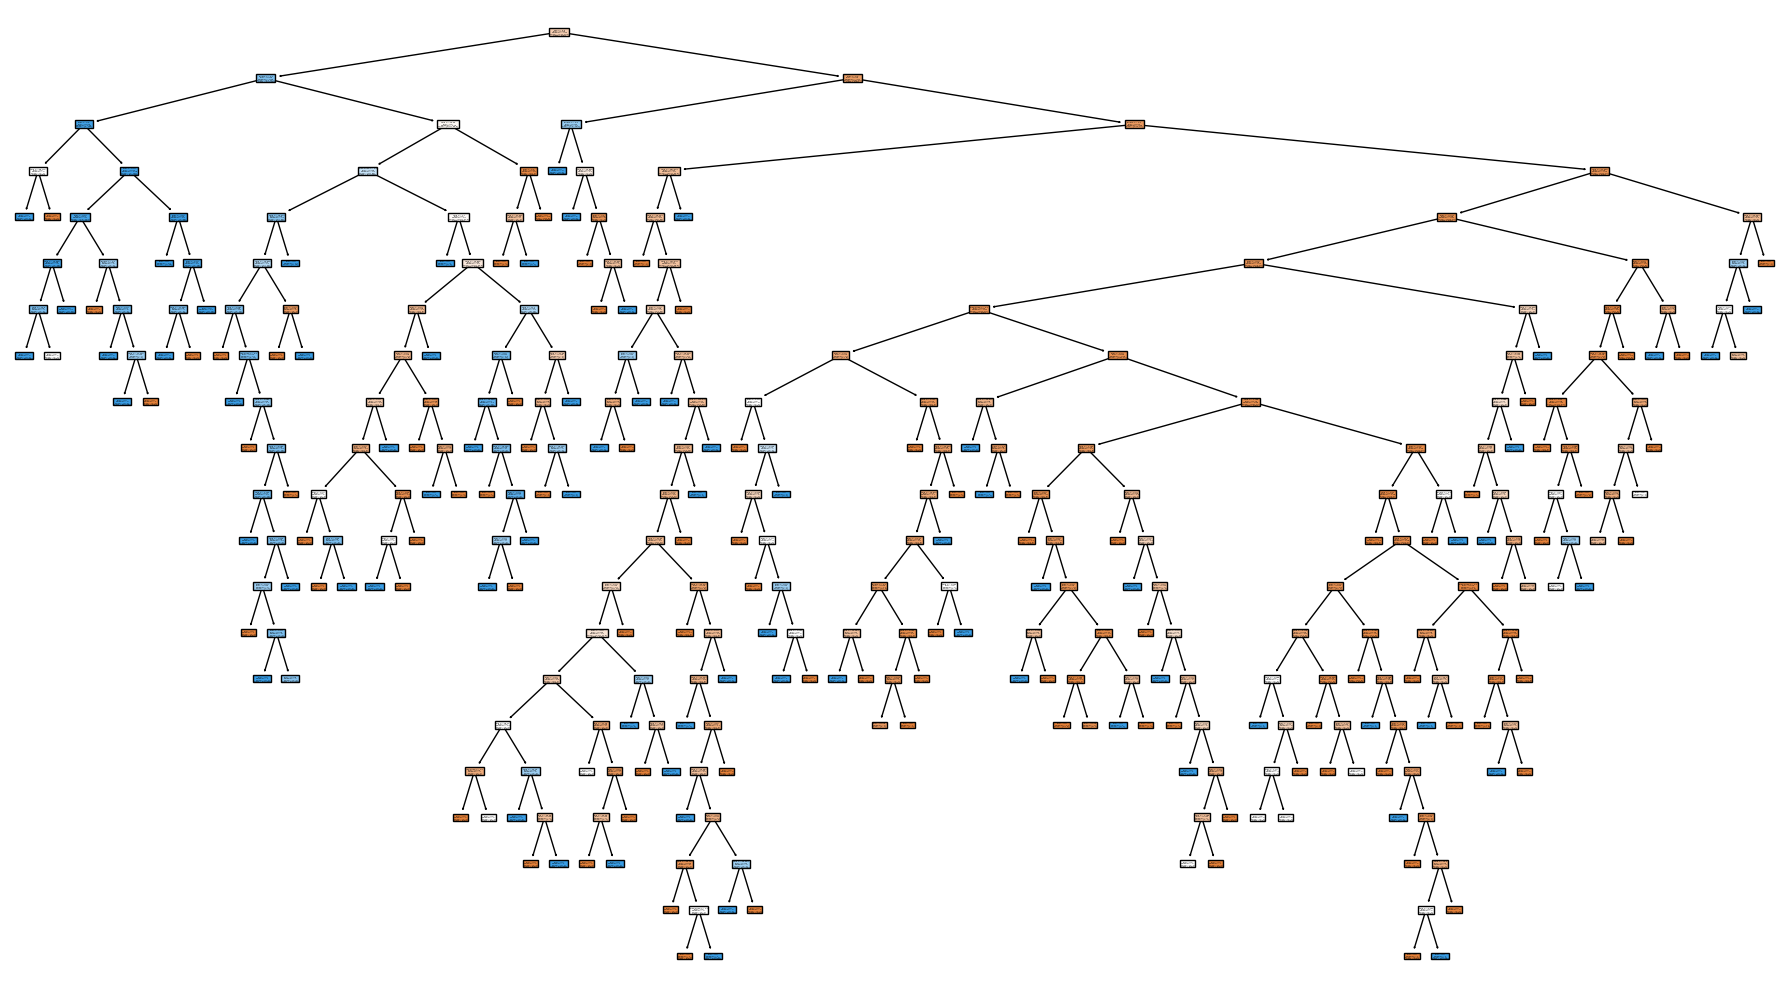

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True
)

plt.tight_layout()
plt.show()

### Decision Tree Pre-Truning

for depth 2, accuracy 0.7653631284916201
for depth 3, accuracy 0.7988826815642458


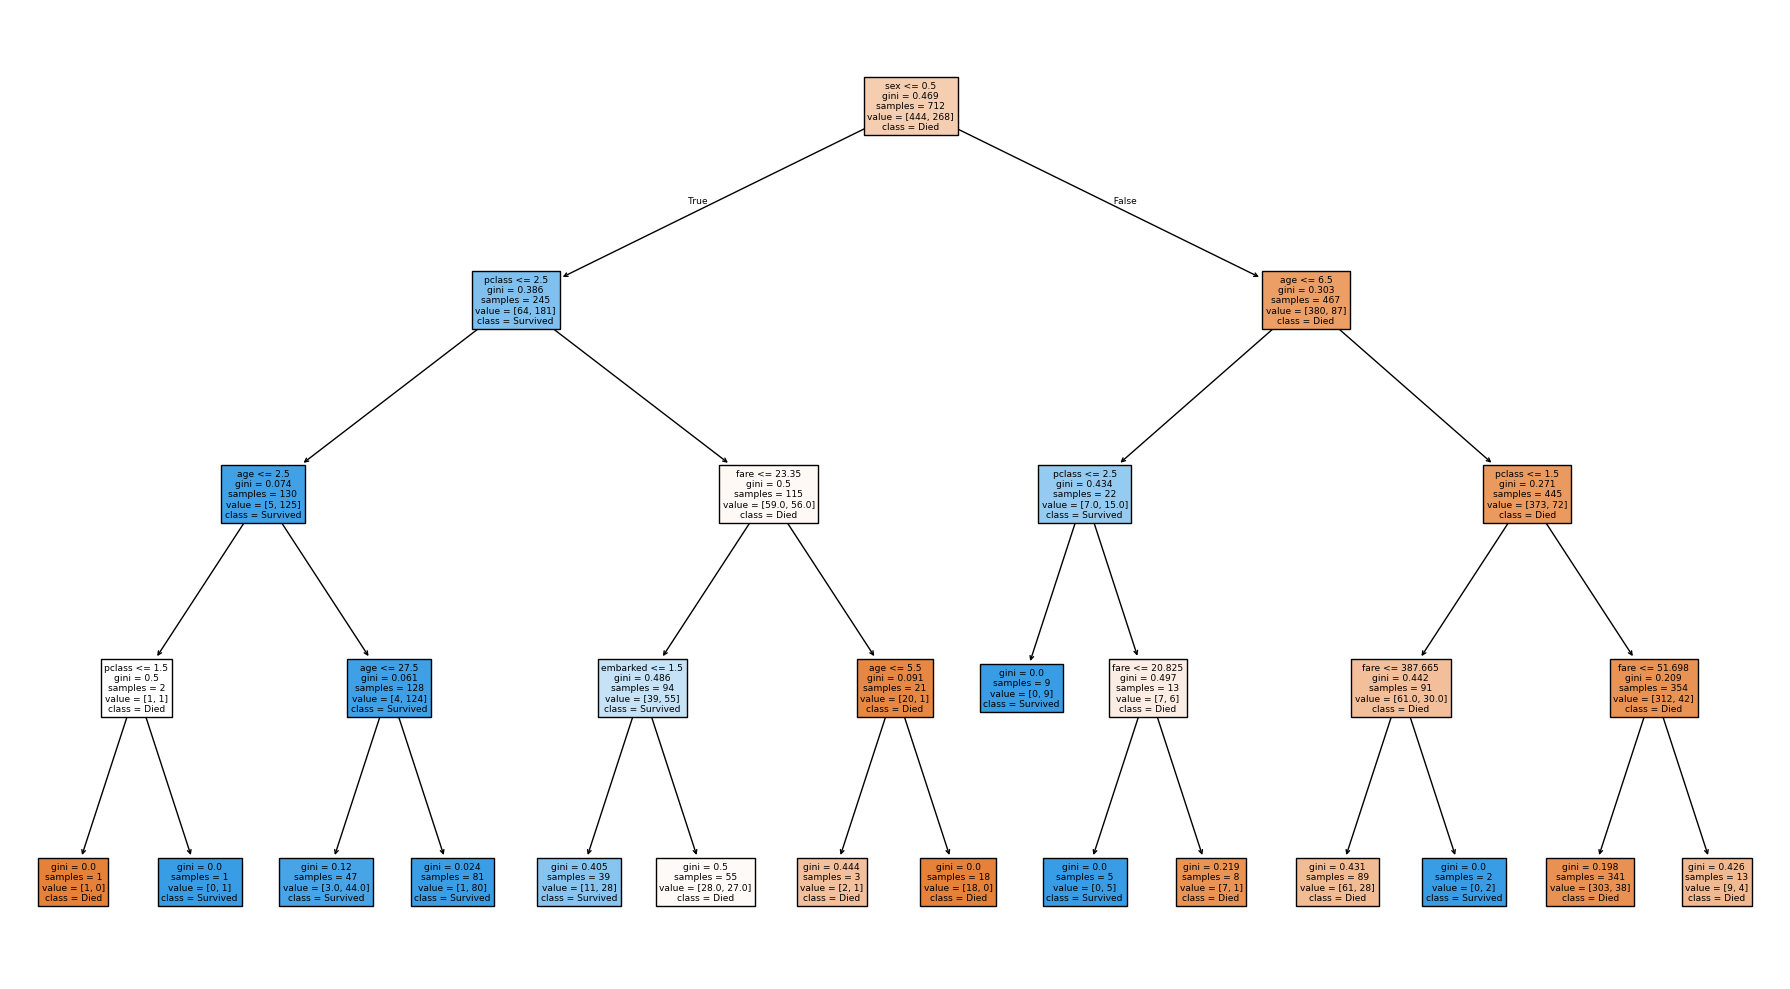

for depth 4, accuracy 0.7988826815642458
for depth 5, accuracy 0.7988826815642458
for depth 6, accuracy 0.8044692737430168
for depth 7, accuracy 0.7932960893854749
for depth 8, accuracy 0.7821229050279329
for depth 9, accuracy 0.7877094972067039


In [16]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9]

for depth in max_depths :
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    if depth == 4 :
        plt.figure(figsize=(18, 10))
        plot_tree(
        model,
        feature_names = X.columns,
        class_names = ["Died", "Survived"],
        filled = True
        )
        plt.tight_layout()
        plt.show()
    acc = model.score(X_test, y_test)
    print(f"for depth {depth}, accuracy {acc}")

for split 5, accuracy 0.7988826815642458


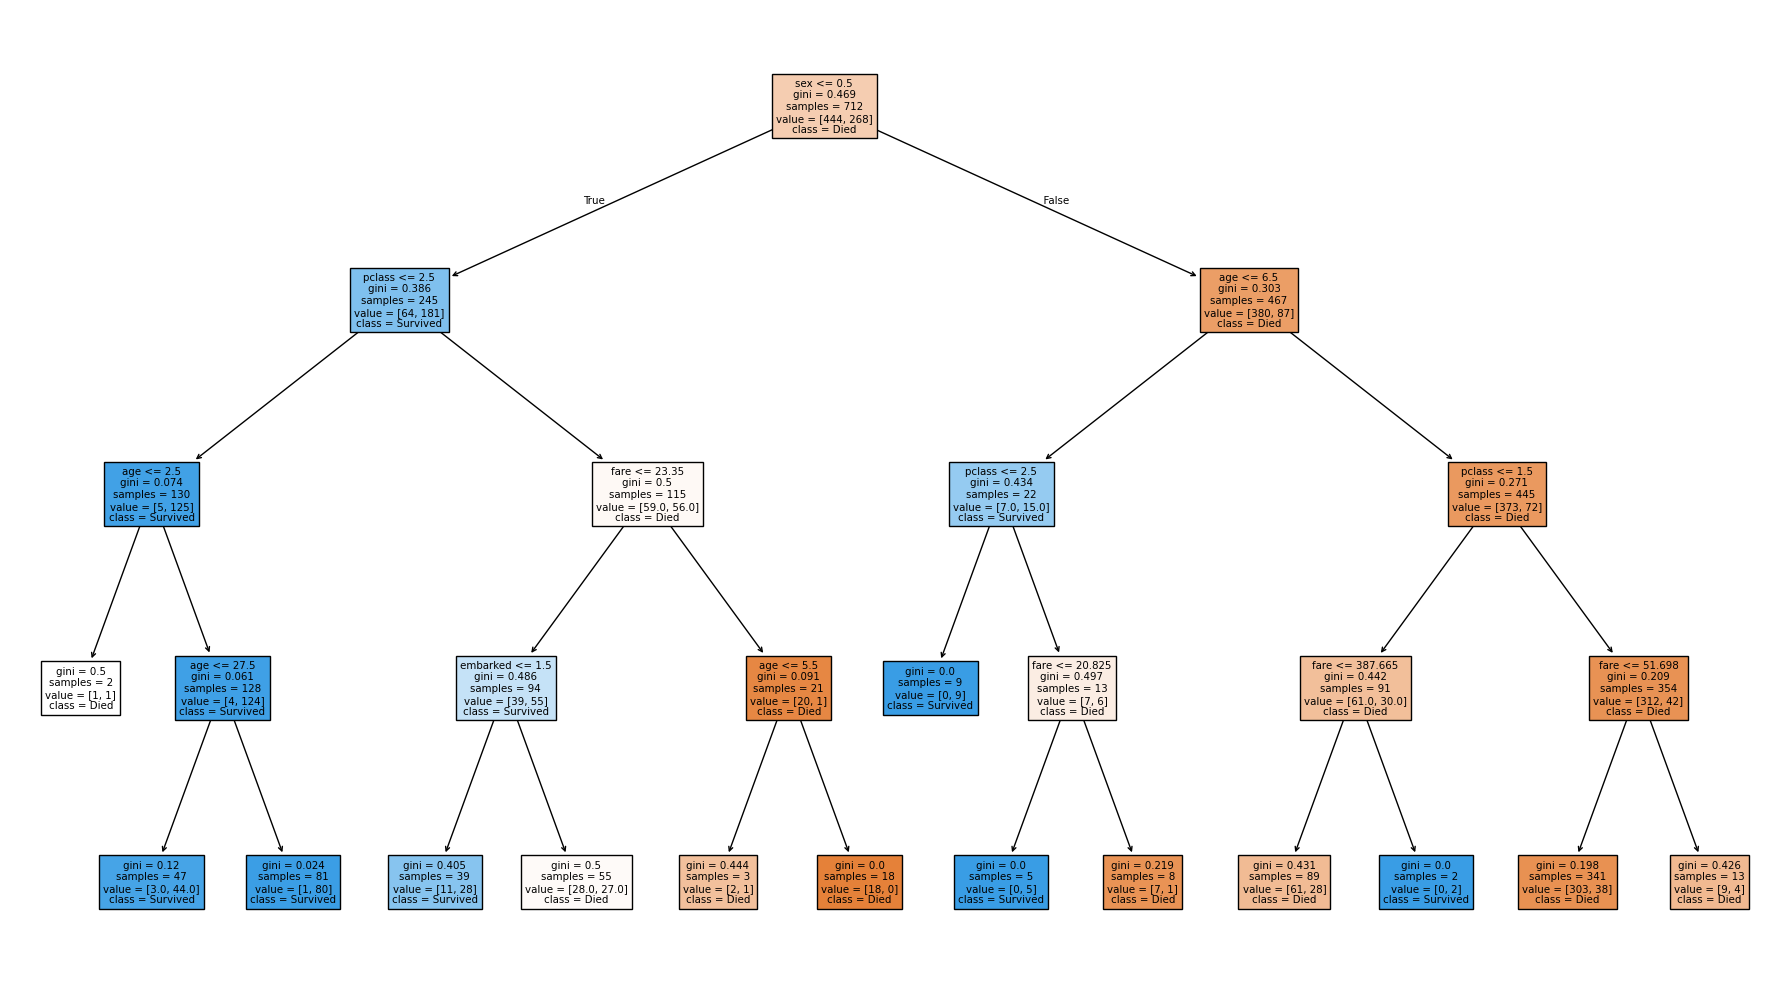

for split 10, accuracy 0.7988826815642458
for split 12, accuracy 0.7988826815642458
for split 15, accuracy 0.7988826815642458
for split 17, accuracy 0.7988826815642458
for split 20, accuracy 0.7988826815642458


In [17]:
min_samples_splits = [5, 10, 12, 15, 17, 20]

for split in min_samples_splits :
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)
    if split == 10 :
        plt.figure(figsize=(18, 10))
        plot_tree(
        model,
        feature_names = X.columns,
        class_names = ["Died", "Survived"],
        filled = True
        )
        plt.tight_layout()
        plt.show()
    acc = model.score(X_test, y_test)
    print(f"for split {split}, accuracy {acc}")

### Decision Tree Post-Pruning

In [18]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [20]:
# train our model for all alphas

trees = []

for alpha in ccp_alphas :
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    trees.append((model, alpha))

    

In [22]:
best_acc = 0
best_alpha = 0

for model, alpha in trees :
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc :
        best_acc = curr_acc
        best_alpha = alpha

In [23]:
best_model = DecisionTreeClassifier(ccp_alpha= best_alpha)
best_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


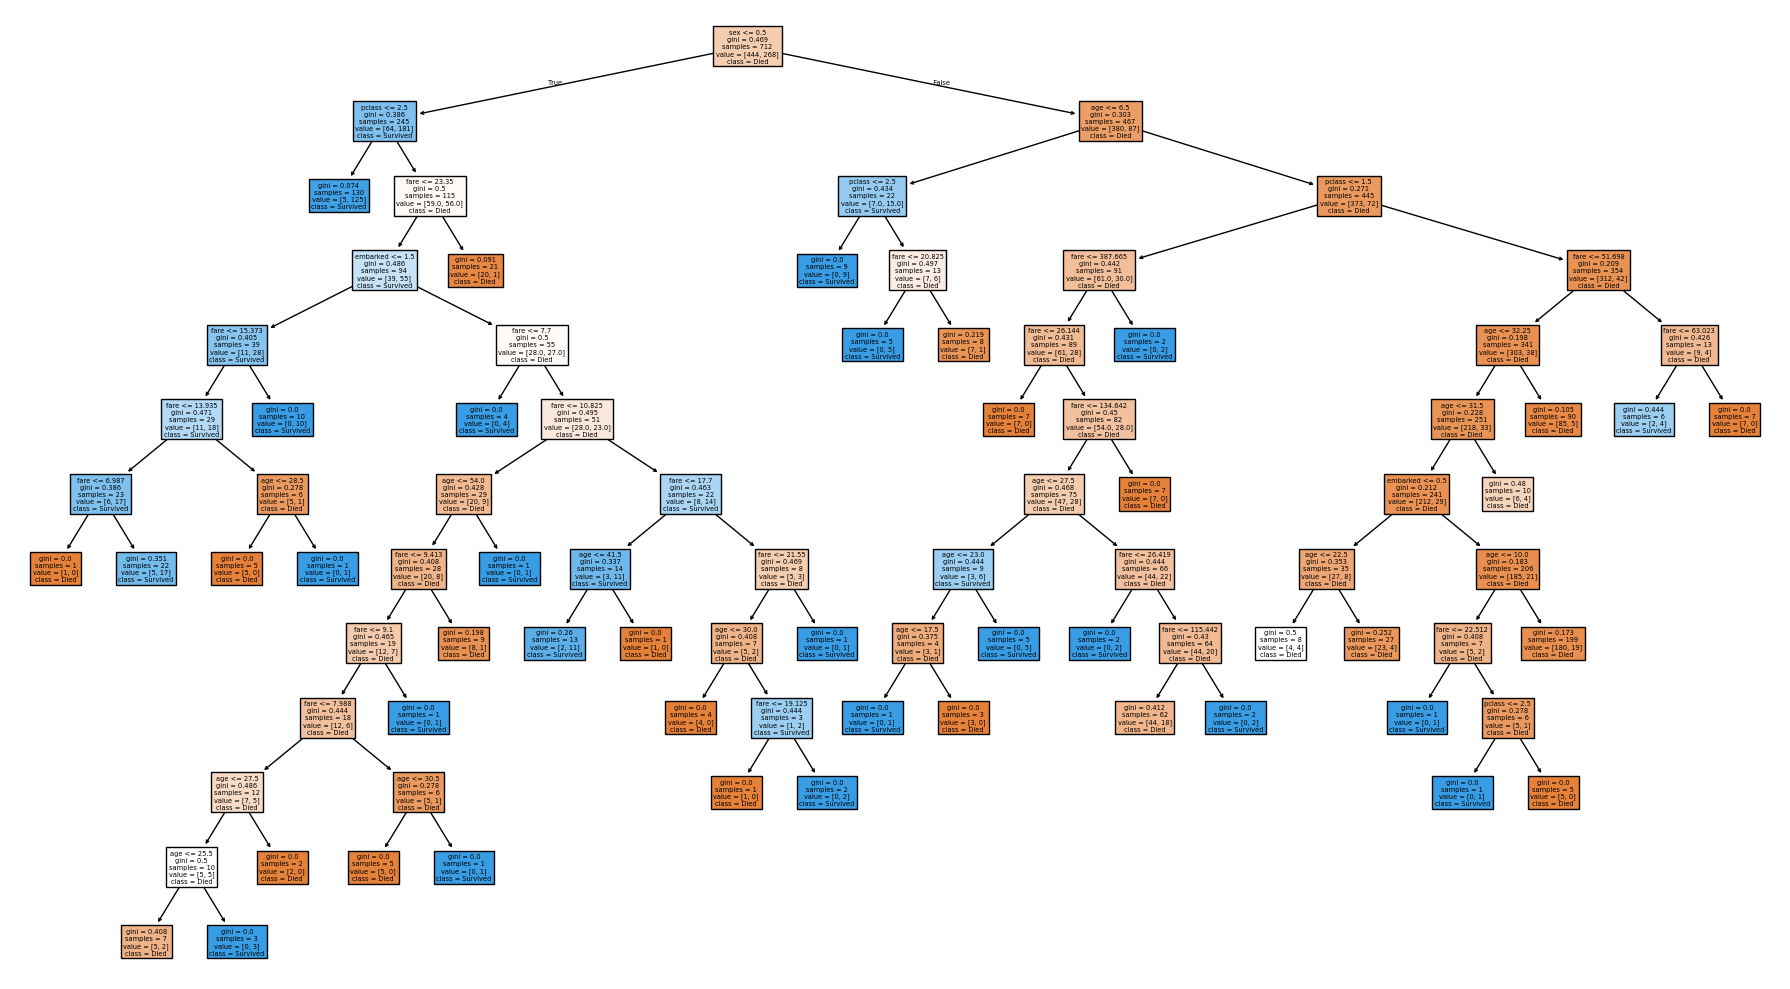

In [24]:
plt.figure(figsize=(18, 10))
plot_tree(
best_model,
feature_names = X.columns,
class_names = ["Died", "Survived"],
filled = True
)
plt.tight_layout()
plt.show()

## Regression

In [25]:
from sklearn.datasets import load_diabetes

In [26]:
diabates = load_diabetes(as_frame=True).frame

In [27]:
diabates.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [29]:
X = diabates.drop("target", axis=1)
y = diabates["target"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

In [38]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=4)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [39]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE train: ", mean_squared_error(y_train, y_pred_train))
print("MSE test: ", mean_squared_error(y_test, y_pred_test))

print("r2 score train: ", r2_score(y_train, y_pred_train))
print("r2 score test: ", r2_score(y_test, y_pred_test))

MSE train:  2450.5062768045877
MSE test:  3545.205844476301
r2 score train:  0.6014323444989667
r2 score test:  0.34327459625277634


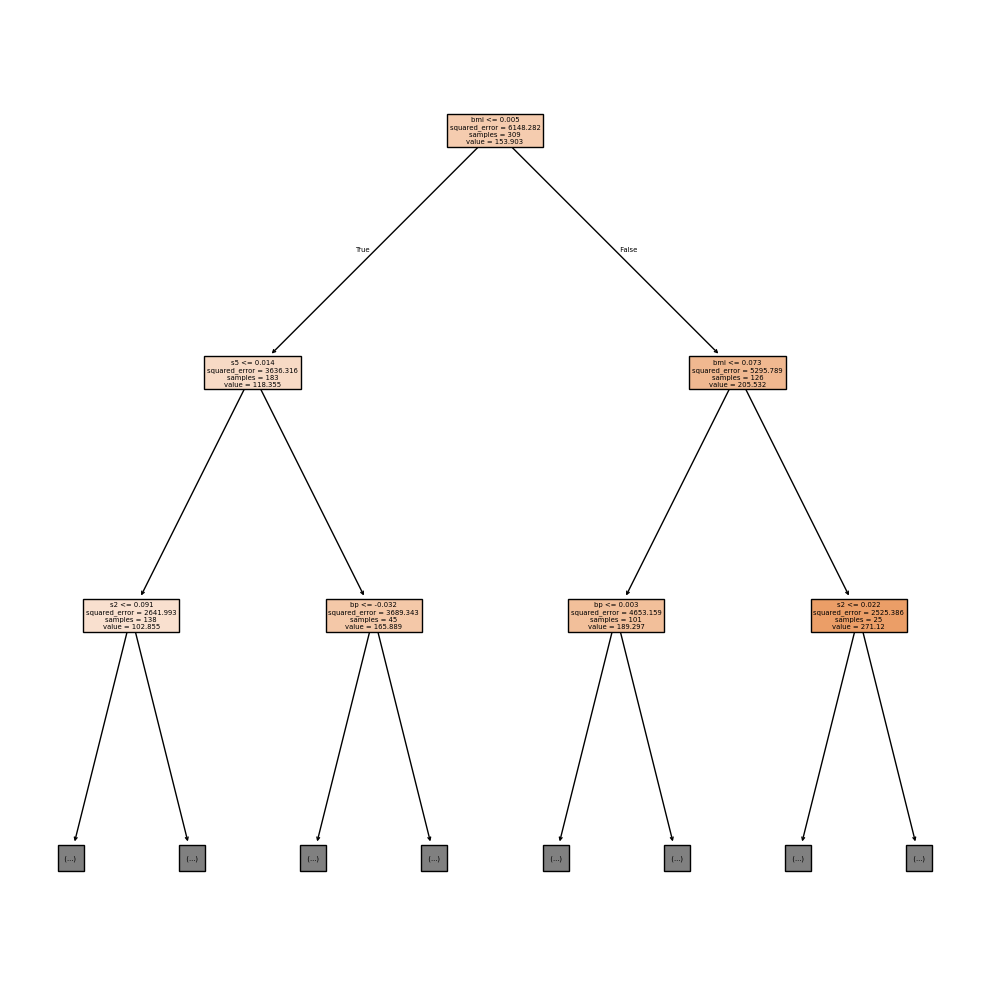

In [37]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,10))

plot_tree(
    model,
    feature_names = X.columns,
    filled = True,
    max_depth = 2
)

plt.tight_layout()
plt.show()